In [1]:
import pandas as pd    
import json
import matplotlib.pyplot as plt
from vllm_server import vlllm_server

MODEL_LIST = [
    "Qwen_Qwen2.5-3B-Instruct-GPTQ-Int8",
    "Qwen_Qwen2.5-1.5B-Instruct",
    "RedHatAI_gemma-2-2b-it-quantized.w4a16",
    "RedHatAI_SmolLM-1.7B-Instruct-quantized.w8a16"
]

MODEL_NAME=MODEL_LIST[2]
REQUEST_RATE="-request_rate10.0"


vllm_server_dict = {}

for MODEL_NAME in MODEL_LIST:
    REQUEST_RATE="-request_rate10.0"
    PATH="../data/artifacts_exp1/" + MODEL_NAME + "-openai-chat" + REQUEST_RATE + "/"
    vllm_server_dict[MODEL_NAME] = vlllm_server(MODEL_NAME, PATH)
    # vllm_server_dict[MODEL_NAME].analyze()
    # vllm_server_dict[MODEL_NAME].compute_intensity()
    # vllm_server_dict[MODEL_NAME].pcie_util_vs_inst_throughput()


[0, 5058, 5428]
[0, 5077, 5446]
[0, 5011, 5381]
[0, 5062, 5431]
[0, 5088, 5458]
[0, 5088, 5457]
[0, 4999, 5369]
[0, 5035, 5404]


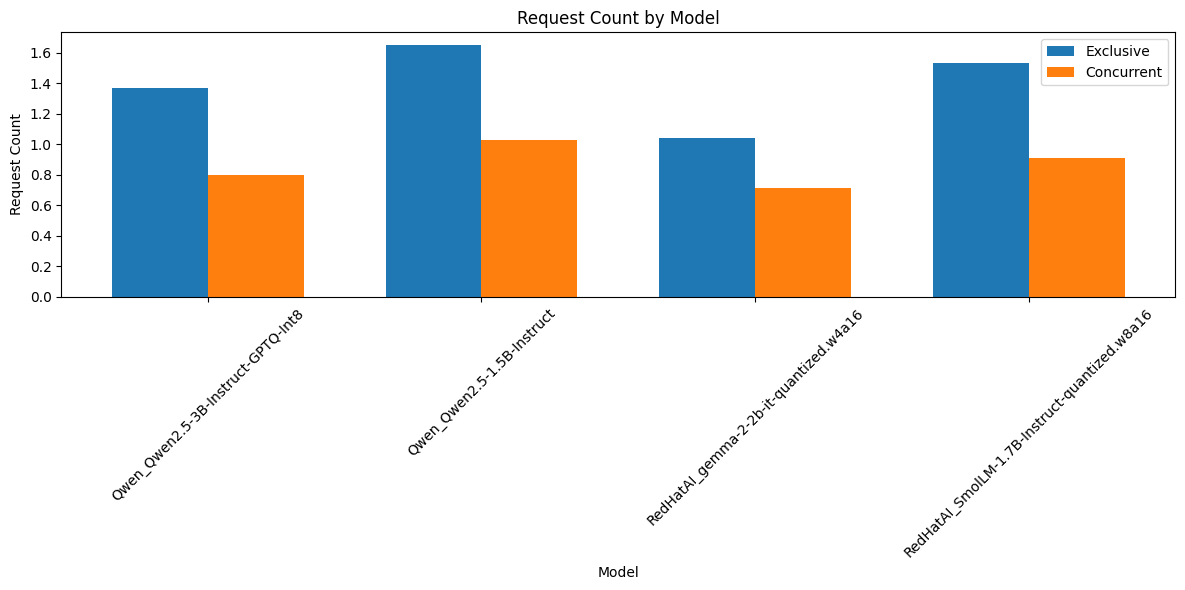

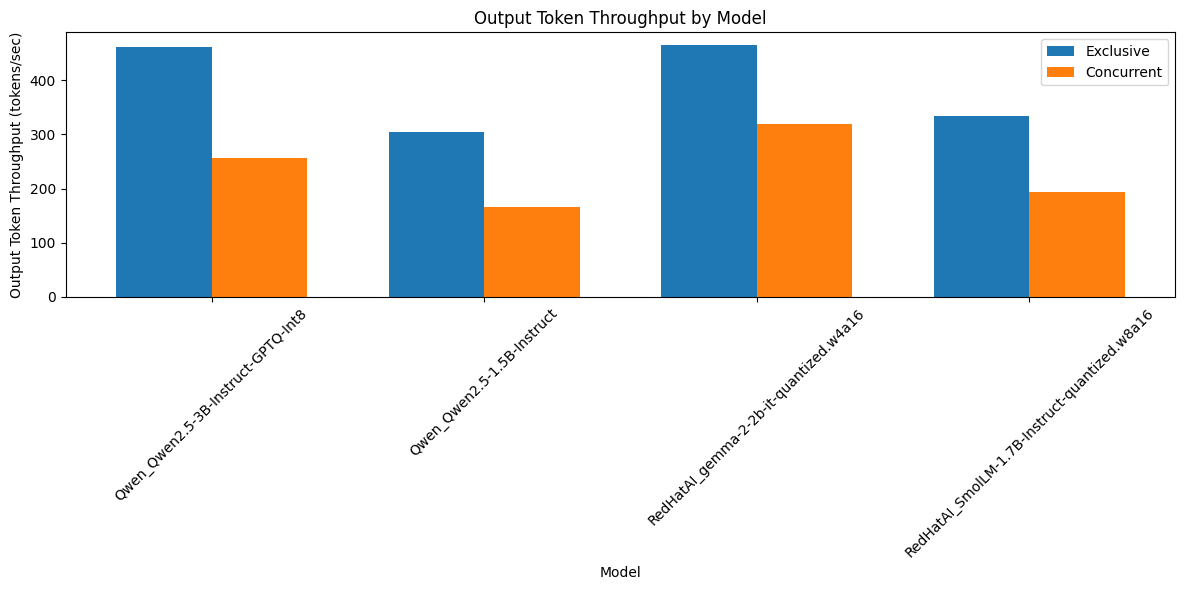

In [12]:
import numpy as np

results = []

for MODEL_NAME in MODEL_LIST:
    for prefix in ["Exclusive", "Concurrent"]:

        df = vllm_server_dict[MODEL_NAME].read_summary_report(prefix)
        results.append({
            "Model": MODEL_NAME,
            "Mode": prefix,
            "Request Count": df.loc[df["Metric"] == "Request Throughput (requests/sec)", "Value"].item(),
            "Output Token Throughput": (
                df.loc[df["Metric"] == "Output Token Throughput (tokens/sec)", "Value"].item()
            ),
        })

results_df = pd.DataFrame(results)

models = MODEL_LIST
x = np.arange(len(models))
width = 0.35

# =============================
# Request Count
# =============================

exclusive = (
    results_df[results_df["Mode"] == "Exclusive"]
    .set_index("Model")
    .reindex(models)
)

concurrent = (
    results_df[results_df["Mode"] == "Concurrent"]
    .set_index("Model")
    .reindex(models)
)

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    exclusive["Request Count"],
    width,
    label="Exclusive"
)

plt.bar(
    x + width / 2,
    concurrent["Request Count"],
    width,
    label="Concurrent"
)

plt.xlabel("Model")
plt.ylabel("Request Count")
plt.title("Request Count by Model")
plt.xticks(x, models, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# =============================
# Output Token Throughput
# =============================

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    exclusive["Output Token Throughput"],
    width,
    label="Exclusive"
)

plt.bar(
    x + width / 2,
    concurrent["Output Token Throughput"],
    width,
    label="Concurrent"
)

plt.xlabel("Model")
plt.ylabel("Output Token Throughput (tokens/sec)")
plt.title("Output Token Throughput by Model")
plt.xticks(x, models, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
import pandas as pd    
import json
import matplotlib.pyplot as plt
from vllm_server import vlllm_server

MODEL_LIST = [
    "Qwen_Qwen2.5-3B-Instruct-GPTQ-Int8",
    "Qwen_Qwen2.5-1.5B-Instruct",
    "RedHatAI_gemma-2-2b-it-quantized.w4a16",
    "RedHatAI_SmolLM-1.7B-Instruct-quantized.w8a16"
]

MODEL_NAME=MODEL_LIST[2]
REQUEST_RATE="-request_rate10.0"


vllm_server_dict = {}

for MODEL_NAME in MODEL_LIST:
    REQUEST_RATE="-request_rate10.0"
    PATH="../data/artifacts_exp2/" + MODEL_NAME + "-openai-chat" + REQUEST_RATE + "/"
    vllm_server_dict[MODEL_NAME] = vlllm_server(MODEL_NAME, PATH)
    # vllm_server_dict[MODEL_NAME].analyze()
    # vllm_server_dict[MODEL_NAME].compute_intensity()
    # vllm_server_dict[MODEL_NAME].pcie_util_vs_inst_throughput()


[0, 5031, 5401]
[0, 5043, 5413]
[0, 4998, 5368]
[0, 4987, 5357]
[0, 5082, 5452]
[0, 5084, 5454]
[0, 4987, 5357]
[0, 4980, 5350]


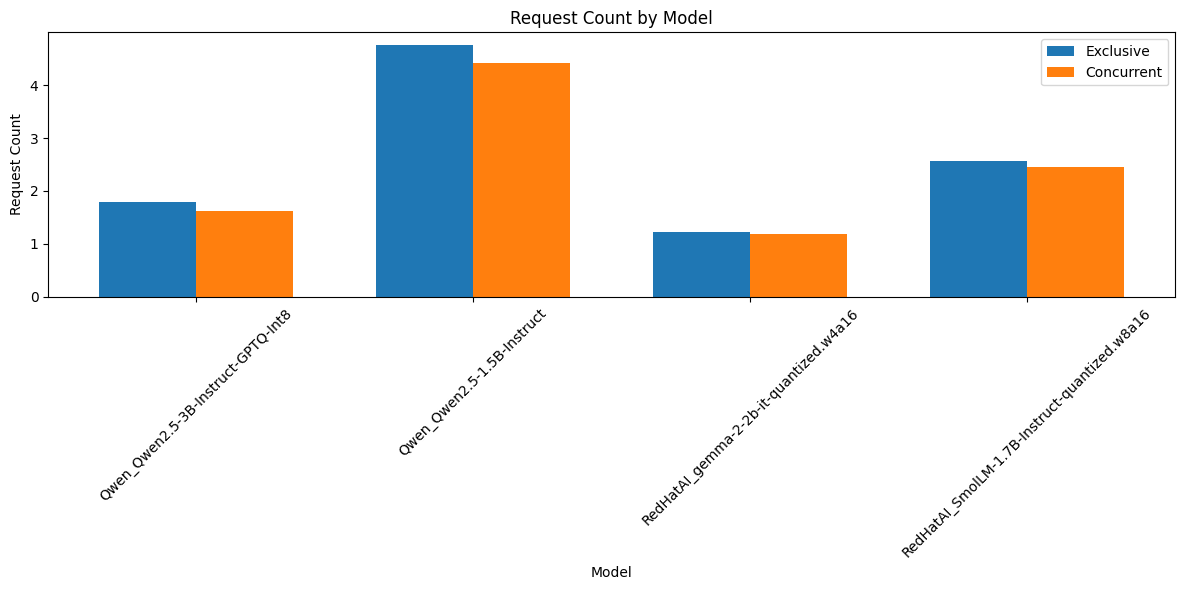

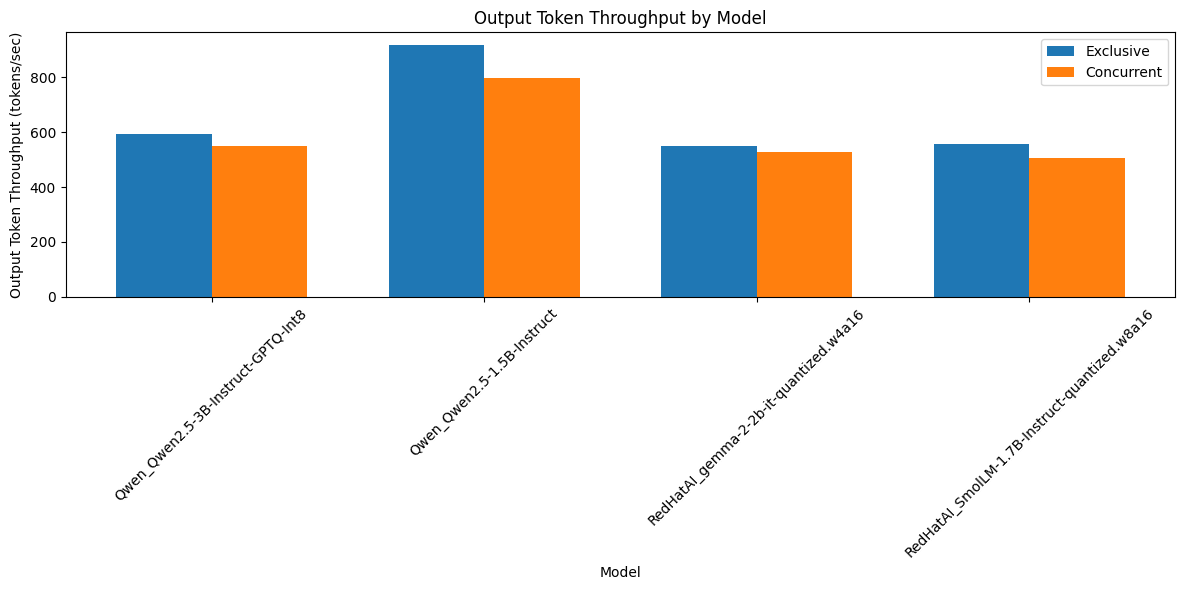

In [14]:
import numpy as np

results = []

for MODEL_NAME in MODEL_LIST:
    for prefix in ["Exclusive", "Concurrent"]:

        df = vllm_server_dict[MODEL_NAME].read_summary_report(prefix)
        results.append({
            "Model": MODEL_NAME,
            "Mode": prefix,
            "Request Count": df.loc[df["Metric"] == "Request Throughput (requests/sec)", "Value"].item(),
            "Output Token Throughput": (
                df.loc[df["Metric"] == "Output Token Throughput (tokens/sec)", "Value"].item()
            ),
        })

results_df = pd.DataFrame(results)

models = MODEL_LIST
x = np.arange(len(models))
width = 0.35

# =============================
# Request Count
# =============================

exclusive = (
    results_df[results_df["Mode"] == "Exclusive"]
    .set_index("Model")
    .reindex(models)
)

concurrent = (
    results_df[results_df["Mode"] == "Concurrent"]
    .set_index("Model")
    .reindex(models)
)

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    exclusive["Request Count"],
    width,
    label="Exclusive"
)

plt.bar(
    x + width / 2,
    concurrent["Request Count"],
    width,
    label="Concurrent"
)

plt.xlabel("Model")
plt.ylabel("Request Count")
plt.title("Request Count by Model")
plt.xticks(x, models, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# =============================
# Output Token Throughput
# =============================

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    exclusive["Output Token Throughput"],
    width,
    label="Exclusive"
)

plt.bar(
    x + width / 2,
    concurrent["Output Token Throughput"],
    width,
    label="Concurrent"
)

plt.xlabel("Model")
plt.ylabel("Output Token Throughput (tokens/sec)")
plt.title("Output Token Throughput by Model")
plt.xticks(x, models, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [3]:

(vllm_server_dict[MODEL_NAME].df_excl['end_perf_ns'].max() - vllm_server_dict[MODEL_NAME].df_excl['start_perf_ns'].min()) / 1e9

np.float64(130.258305269)